# Give Me Some Credit

## Import libraries, functions and data

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
import jax
import jax.numpy as jnp

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
from xgboost import XGBClassifier

from google.colab import drive

In [35]:
def plot_roc_curve(fpr, tpr, label="ROC Curve"):
    plt.figure(figsize=(6, 6))

    plt.plot(fpr, tpr, label=label)
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')

    plt.axis([0, 1, 0, 1])
    plt.xlabel("False Positive Rate (1 - SPECIFICITY)")
    plt.ylabel("True Positive Rate (SENSITIVITY)")
    plt.title(label)

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [36]:
train_df = pd.read_csv("train.csv")
print(train_df.shape)
test_df = pd.read_csv("test.csv")

(104805, 12)


## Exploratory data analysis

In [37]:
train_df.head()

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
1,2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
2,3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
3,4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
4,5,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0


In [9]:
test_df.head()

,Id,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,9,0.189169,57,0,0.606291,23684.0,9,0,4,0,2.0
2,17,0.166284,53,0,0.188274,8800.0,7,0,0,0,0.0
3,18,0.221813,43,0,0.527888,3280.0,7,0,1,0,2.0
4,24,0.046560,58,0,0.241622,2416.0,9,0,1,0,0.0


In [10]:
train_df.rename(columns={'Unnamed: 0':'ID'}, inplace=True)
test_df.rename(columns={'Unnamed: 0':'ID'}, inplace=True)

In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104805 entries, 0 to 104804
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Id                                    104805 non-null  int64  
 1   SeriousDlqin2yrs                      104805 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  104805 non-null  float64
 3   age                                   104805 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  104805 non-null  int64  
 5   DebtRatio                             104805 non-null  float64
 6   MonthlyIncome                         84024 non-null   float64
 7   NumberOfOpenCreditLinesAndLoans       104805 non-null  int64  
 8   NumberOfTimes90DaysLate               104805 non-null  int64  
 9   NumberRealEstateLoansOrLines          104805 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  104805 non-null  int64  
 11  

In [12]:
train_df.describe().round(decimals=2)

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,104805.00,104805.00,104805.00,104805.00,104805.00,104805.00,84024.00,104805.00,104805.00,104805.00,104805.00,102056.00
mean,75013.71,0.07,5.60,52.35,0.42,354.86,6684.45,8.45,0.26,1.02,0.24,0.76
std,43324.04,0.25,217.39,14.77,4.14,2169.18,15653.13,5.13,4.12,1.14,4.10,1.11
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,37508.00,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,74931.00,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,112620.00,0.00,0.56,63.00,0.00,0.87,8250.00,11.00,0.00,2.00,0.00,1.00
max,149999.00,1.00,29110.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,13.00


In [ ]:
# fix RevolvingUtilizationOfUnsecuredLines and DebtRatio: max can't be that high!

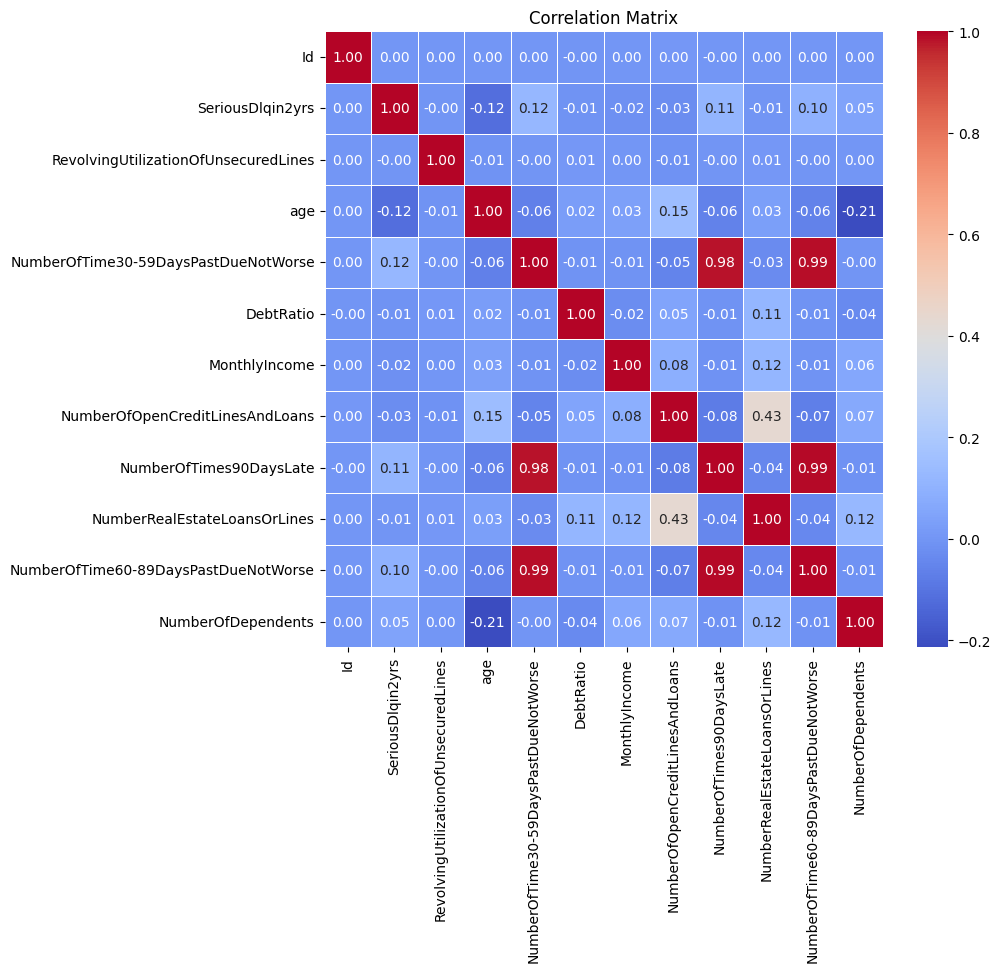

In [13]:
corr = train_df.corr()
fig = plt.figure(figsize=(9,8))
plt.title('Correlation Matrix')
ax = sns.heatmap(corr, annot=True, fmt='.2f', cmap="coolwarm", linewidths=0.5)
plt.show()

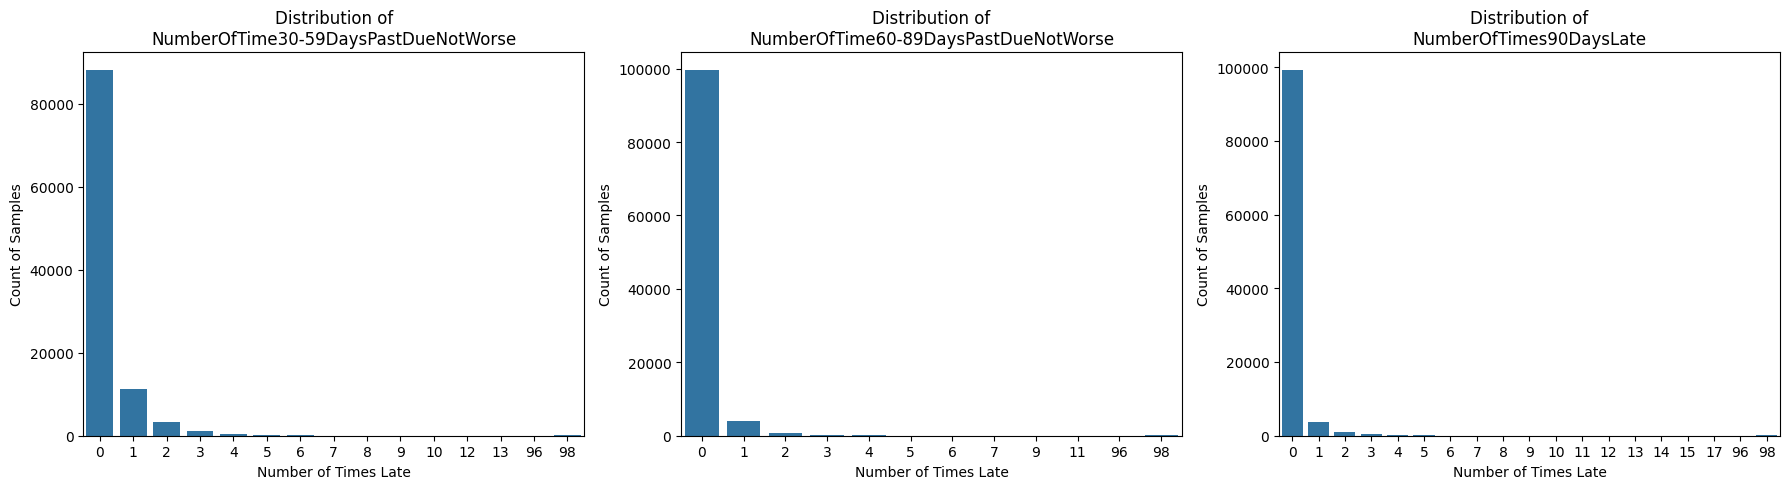

In [14]:
late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(late_cols):
    sns.countplot(
        data=train_df,
        x=col,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of\n{col}')
    axes[i].set_xlabel('Number of Times Late')
    axes[i].set_ylabel('Count of Samples')
plt.tight_layout()
plt.show()

In [15]:
wrong_mask = (train_df[late_cols[0]].isin([96, 98])) | \
             (train_df[late_cols[1]].isin([96, 98])) | \
             (train_df[late_cols[2]].isin([96, 98]))
wrong_samples = train_df[wrong_mask]

combinations_table = wrong_samples[late_cols].value_counts().reset_index(name='Count')
# wrong_samples[late_cols]: filtered dataset with corrupted rows only
# .value_counts(): it looks for rows that has the same three numbers and counts how many times that combination appears
# .reset_index(name='Count'): it flattens the .value_counts() output into a standard dataframe

print("There are " + str(len(wrong_samples)) + " corrupted samples:")
combinations_table.style.hide(axis="index")

There are 183 corrupted samples:


NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,Count
98,98,98,181
96,96,96,2


In [16]:
print(train_df.duplicated().value_counts())
print(test_df.duplicated().value_counts())
# no duplicated rows (all False)

False    104805
Name: count, dtype: int64
False    45195
Name: count, dtype: int64


In [17]:
mis_val = train_df.isnull().sum()
mis_val_percent = 100 * train_df.isnull().sum() / len(train_df)
mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
mis_val_table_ren_columns = mis_val_table.rename(
columns = {0 : 'Missing Values', 1 : '% of Total Values'})
mis_val_table_ren_columns = mis_val_table_ren_columns[
    mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
'% of Total Values', ascending=False).round(1)
print ("There are " + str(mis_val_table_ren_columns.shape[0]) +
      " columns that have missing values:")
mis_val_table_ren_columns

There are 2 columns that have missing values:


,Missing Values,% of Total Values
MonthlyIncome,20781,19.8
NumberOfDependents,2749,2.6


## Imputing

We fix *age*, *MonthlyIncome* and *NumberOfDependents*

In [38]:
age_median = train_df.loc[train_df['age'] > 0, 'age'].median()
inc_median = train_df['MonthlyIncome'].median()
dep_median = train_df['NumberOfDependents'].median()

datasets = [train_df, test_df]

for df in datasets:
    df.loc[df['age'] == 0, 'age'] = age_median
    df['age'] = df['age'].astype(int)

    df['MonthlyIncome'] = df['MonthlyIncome'].fillna(inc_median)
    df['NumberOfDependents'] = df['NumberOfDependents'].fillna(dep_median).astype(int)

We fix *NumberOfTime30-59DaysPastDueNotWorse*, *NumberOfTime60-89DaysPastDueNotWorse* and *NumberOfTimes90DaysLate*

In [39]:
safe_medians = {}
for col in late_cols:
    valid_data = train_df.loc[~train_df[col].isin([96, 98]), col]
    safe_medians[col] = valid_data.median()

for df in datasets:
    for col in late_cols:
        df.loc[df[col].isin([96, 98]), col] = safe_medians[col]
        df[col] = df[col].astype(int)

## More data analysis

In [40]:
train_df.describe().round(decimals=2)

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,104805.00,104805.00,104805.00,104805.00,104805.00,104805.00,104805.00,104805.00,104805.00,104805.00,104805.00,104805.00
mean,75013.71,0.07,5.60,52.35,0.24,354.86,6429.77,8.45,0.09,1.02,0.06,0.74
std,43324.04,0.25,217.39,14.77,0.70,2169.18,14024.95,5.13,0.49,1.14,0.33,1.10
min,1.00,0.00,0.00,21.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,37508.00,0.00,0.03,41.00,0.00,0.18,3900.00,5.00,0.00,0.00,0.00,0.00
50%,74931.00,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,112620.00,0.00,0.56,63.00,0.00,0.87,7400.00,11.00,0.00,2.00,0.00,1.00
max,149999.00,1.00,29110.00,109.00,13.00,329664.00,3008750.00,58.00,17.00,54.00,11.00,13.00


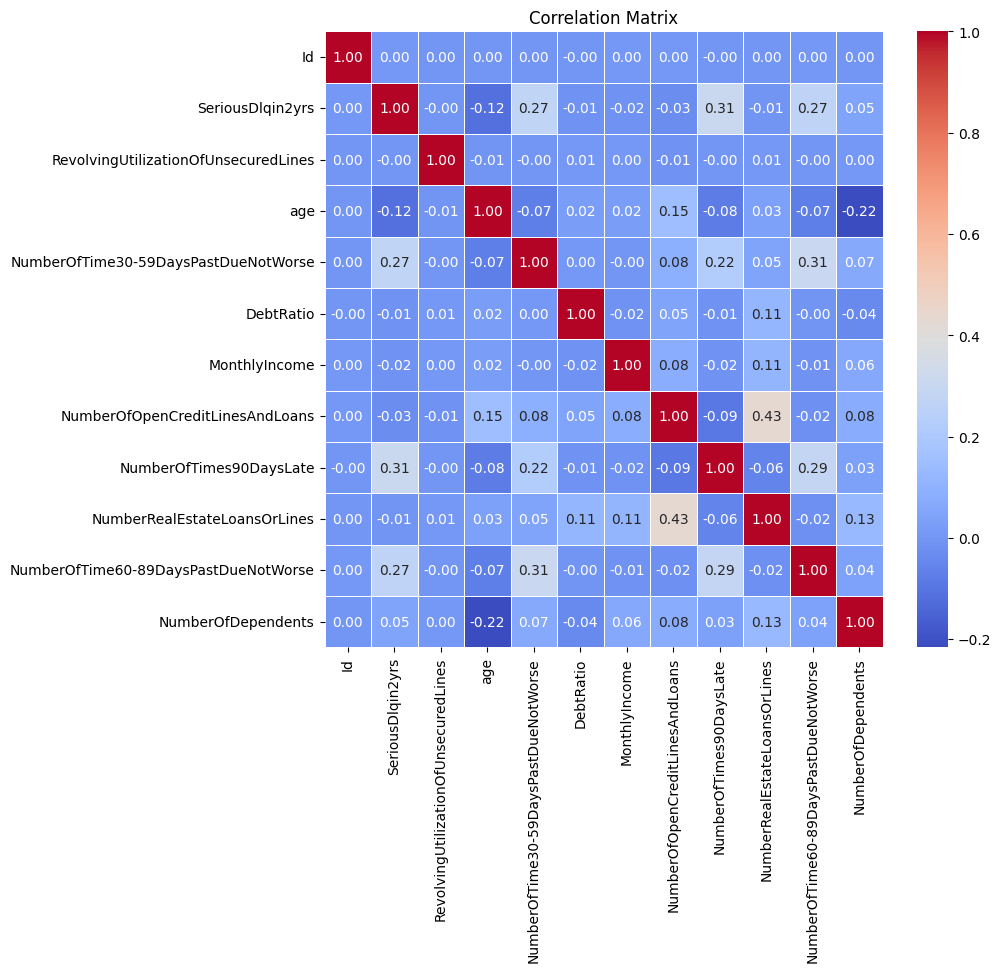

In [41]:
corr = train_df.corr()
fig = plt.figure(figsize=(9,8))
plt.title('Correlation Matrix')
ax = sns.heatmap(corr, annot=True, fmt='.2f', cmap="coolwarm", linewidths=0.5)
plt.show()

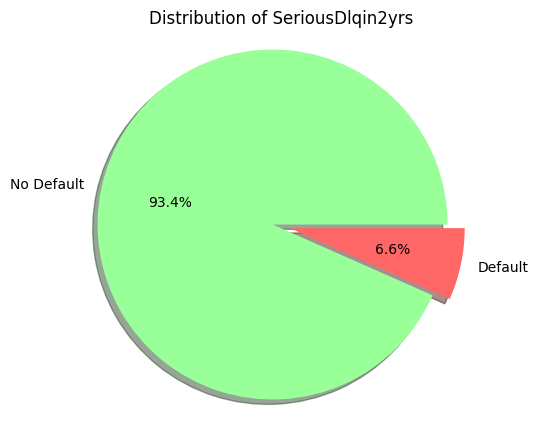

In [42]:
target_counts = train_df['SeriousDlqin2yrs'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(
    target_counts,
    labels=['No Default', 'Default'],
    autopct='%1.1f%%', # it automatically computes percentages
    colors=['#99ff99', '#ff6666'],
    explode=(0, 0.1), # highlight the Default slice
    shadow=True
)
plt.title('Distribution of SeriousDlqin2yrs')
plt.axis('equal')
plt.show()

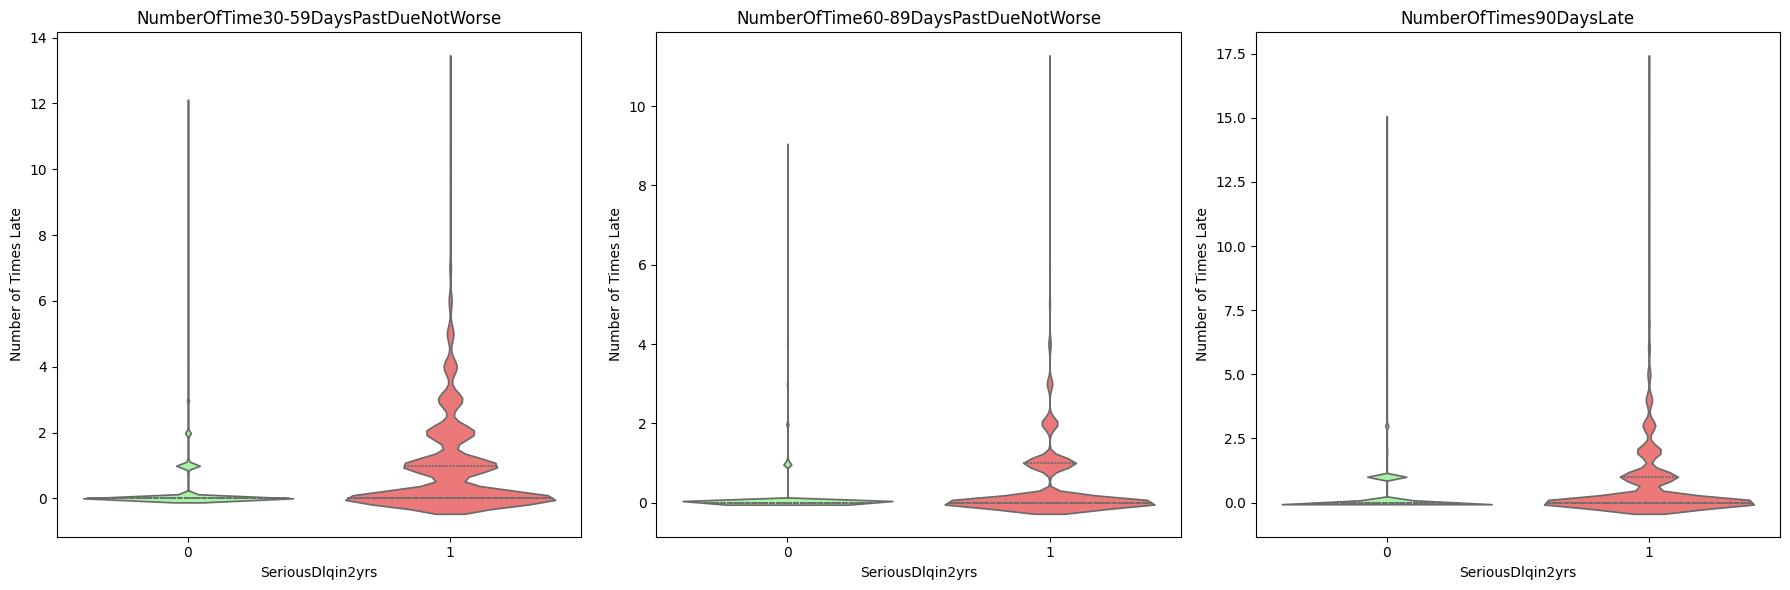

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, feature in enumerate(late_cols):
    sns.violinplot(
        data=train_df,
        x='SeriousDlqin2yrs',
        y=feature,
        ax=axes[i],
        hue='SeriousDlqin2yrs',
        palette=['#99ff99', '#ff6666'],
        inner='quartile',
        legend=False
    )
    axes[i].set_title(feature)
    axes[i].set_xlabel('SeriousDlqin2yrs')
    axes[i].set_ylabel('Number of Times Late')
plt.tight_layout()
plt.show()

In [ ]:
# add some other visualizations

## Model

In [44]:
print(train_df.shape)
X = train_df.drop(['SeriousDlqin2yrs', 'Id'], axis=1)
y = train_df['SeriousDlqin2yrs']

#W = test_df.drop(['SeriousDlqin2yrs', 'Id'], axis=1)
#z = test_df['SeriousDlqin2yrs']

(104805, 12)


In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123, test_size = 0.2)

train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

## Logistic Regression

In [46]:
X_train_array = np.array(X_train_scaled)
y_train_array = np.array(y_train)
X_test_array = np.array(X_test_scaled)
y_test_array = np.array(y_test)

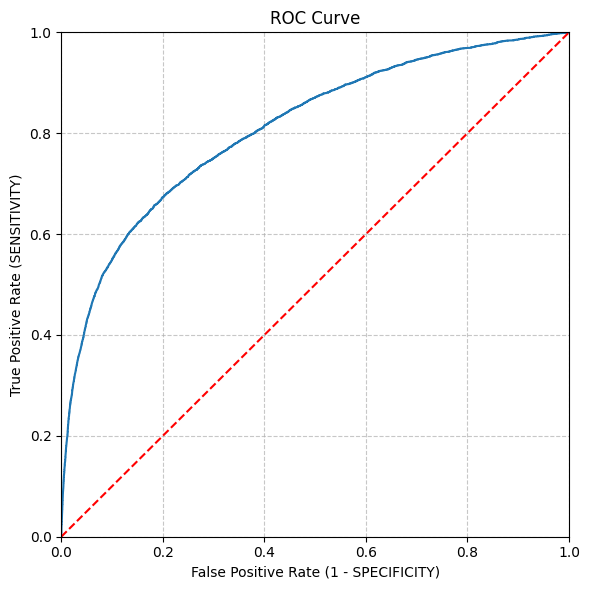

AUC Score: 0.8098953113811226


In [47]:
#here a built in imputer is used to eliminate NANs- why is it needed? didnt we already eliminate them? TO CHECK
imputer = SimpleImputer(strategy='mean')
X_train_array_lr = imputer.fit_transform(X_train_scaled)
X_test_array_lr = imputer.transform(X_test_scaled)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_array_lr, y_train_array)

# Predict probabilities on train set
lr_probs = model.predict_proba(X_train_array_lr)[:, 1]
fpr_lr, tpr_lr, thresh = roc_curve(y_train,lr_probs )
plot_roc_curve(fpr_lr,tpr_lr)
print('AUC Score:', (roc_auc_score(y_train, lr_probs)))





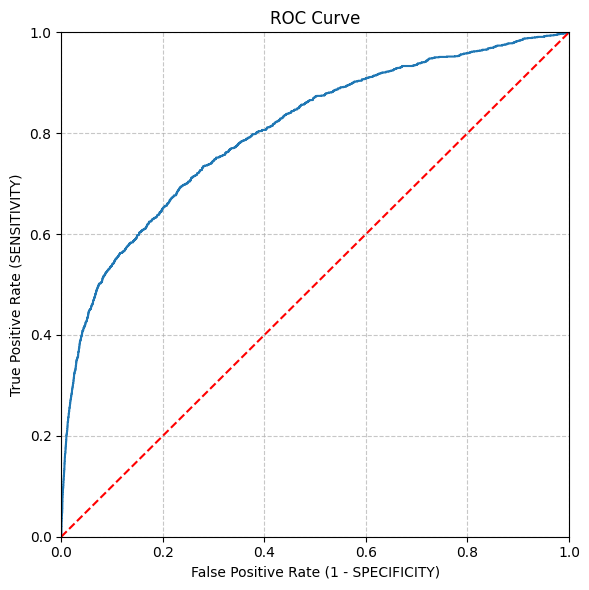

AUC Score: 0.8034270514846972


In [48]:
#predict probabilities on test set
lr_scores_proba = model.predict_proba(X_test_array_lr)
lr_preds = lr_scores_proba[:, 1]
lr_fpr, lr_tpr, threshold = roc_curve(y_test, lr_preds)
plot_roc_curve(lr_fpr, lr_tpr)
print('AUC Score:', roc_auc_score(y_test, lr_preds))

## ANN

In [53]:
def initialize_params(layers_size):
    np.random.seed(0)
    params = list()
    for i in range(len(layers_size) - 1):
        # Xavier/Glorot Initialization
        W = np.random.randn(layers_size[i + 1], layers_size[i]) * np.sqrt(
            2 / (layers_size[i + 1] + layers_size[i])
        )
        b = np.zeros((layers_size[i + 1], 1))
        params.append((W, b))
    return params

def ANN(x, params):
    layer = x.T
    for i, (W, b) in enumerate(params):
        layer = W @ layer - b
        if i < len(params) - 1:
            layer = jnp.tanh(layer)
        else:
            layer = jax.nn.sigmoid(layer)
    return layer.T

def loss(x, y, params):
    preds = ANN(x, params)
    # ensure y has the same shape as preds
    y = y.reshape(preds.shape)
    # clip to prevent taking log(0) which causes NaNs
    preds = jnp.clip(preds, 1e-15, 1 - 1e-15)
    # Binary Cross-Entropy
    bce = -jnp.mean(y * jnp.log(preds) + (1 - y) * jnp.log(1 - preds))
    return bce

In [54]:
input_size = X_train_array.shape[1]
layers_size = [input_size, 20, 20, 1]
num_epochs = 200
learning_rate_max = 1e-1
learning_rate_min = 1e-2
learning_rate_decay = num_epochs
batch_size = 1000

params = initialize_params(layers_size)

grad = jax.jit(jax.grad(loss, argnums=2)) # params is the 3rd argument
loss_jit = jax.jit(loss)
grad_jit = jax.jit(grad)

n_samples = X_train_array.shape[0]

history_train = list()
history_valid = list()

for epoch in range(num_epochs):
    lr = max(
        learning_rate_min, learning_rate_max * (1 - epoch / learning_rate_decay)
    )
    perm = np.random.permutation(n_samples)
    for i in range(0, n_samples, batch_size):
        batch_idx = perm[i : i + batch_size]
        x_batch = X_train_array[batch_idx]
        y_batch = y_train_array[batch_idx]

        grads = grad_jit(x_batch, y_batch, params)
        params = jax.tree_util.tree_map(lambda p, g: p - lr * g, params, grads)

    history_train.append(loss_jit(X_train_array, y_train_array, params))
    history_valid.append(loss_jit(X_test_array, y_test_array, params))

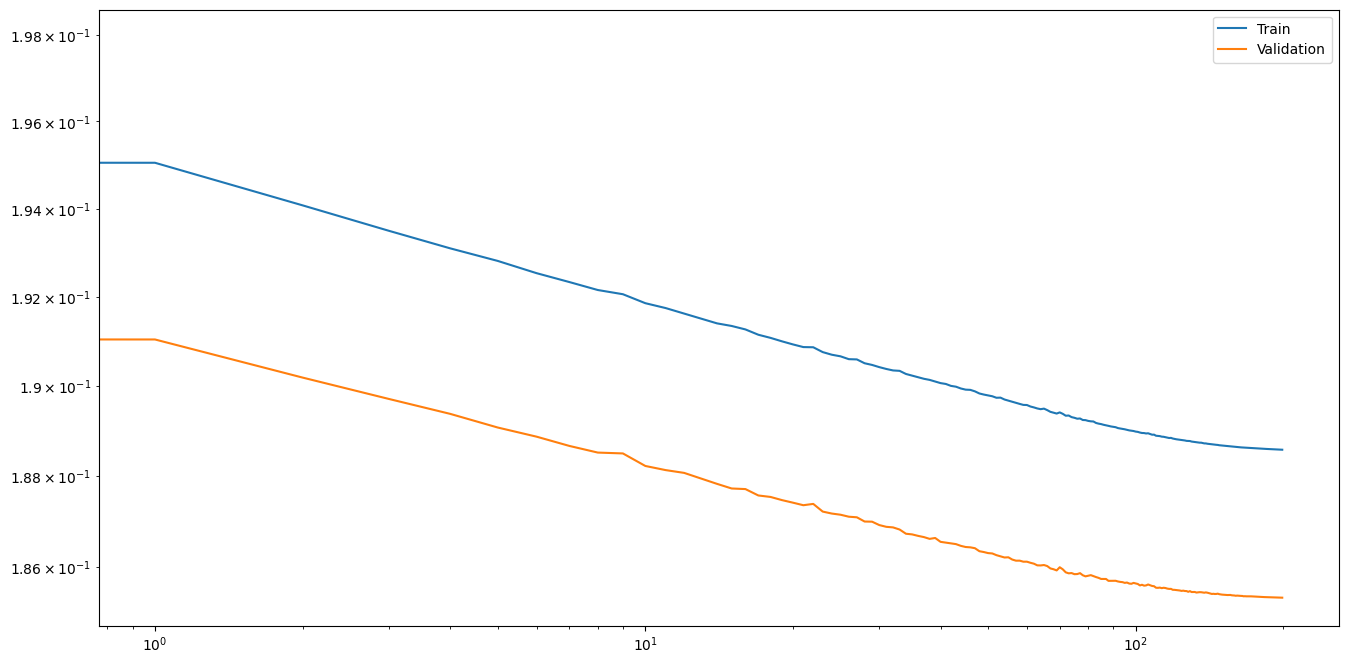

In [ ]:
# plotting the loss curves
fig, axs = plt.subplots(1, figsize=(16, 8))
axs.loglog(history_train, label="Train")
axs.loglog(history_valid, label="Validation")
plt.legend()
plt.show()

In [55]:
y_pred_probs = ANN(X_test_array, params)
print('AUC Score:', (roc_auc_score(y_test_array, y_pred_probs)))

AUC Score: 0.8252911314745336


## Random Forest

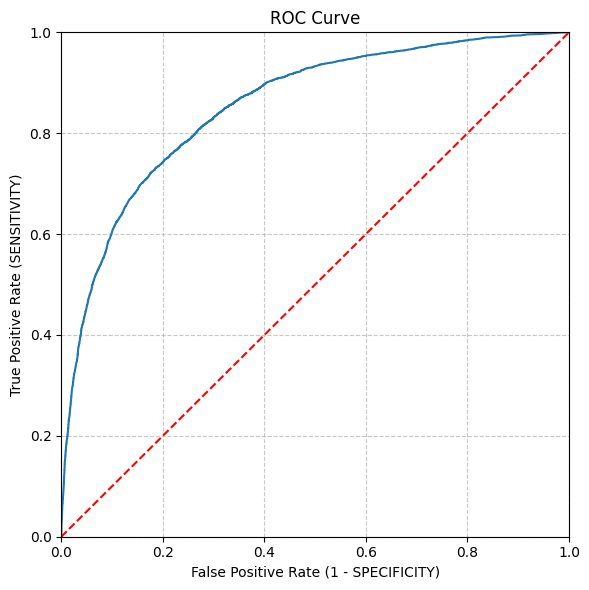

AUC Score: 0.853620493891436


In [49]:
clf = RandomForestClassifier(random_state=123, max_depth=3, n_estimators=300, class_weight='balanced')
clf.fit(X_train_scaled, y_train)
clf_scores_proba = clf.predict_proba(X_train_scaled)
clf_preds = clf_scores_proba[:, 1]
fpr, tpr, thresh = roc_curve(y_train, clf_preds)
plot_roc_curve(fpr,tpr)
print('AUC Score:', (roc_auc_score(y_train, clf_preds)))

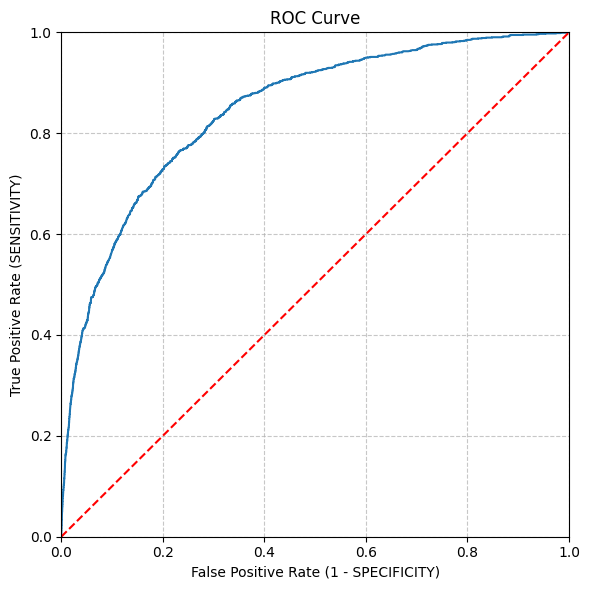

AUC Score: 0.845548736888726


In [50]:
clf_scores_proba = clf.predict_proba(X_test_scaled)
clf_preds = clf_scores_proba[:, 1]
fpr, tpr, threshold = roc_curve(y_test, clf_preds)
plot_roc_curve(fpr, tpr)
print('AUC Score:', roc_auc_score(y_test, clf_preds))

## XG Boost

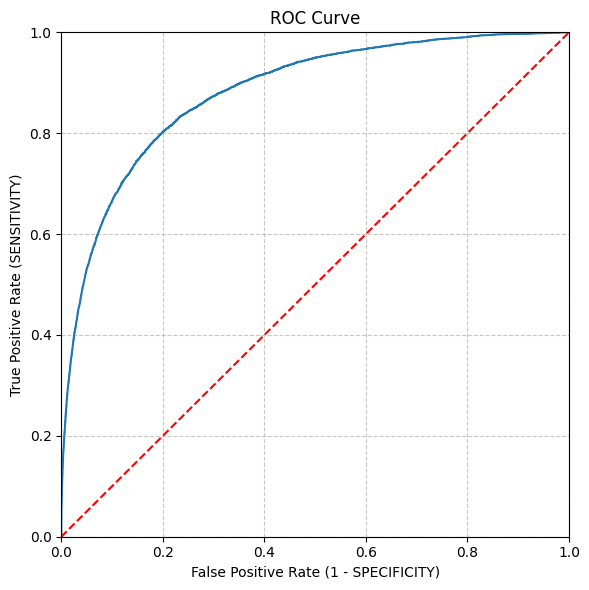

AUC Score: 0.8813880714839151


In [51]:
clf = XGBClassifier(random_state=123, n_estimators=150, learning_rate=0.05, max_depth=5)
clf.fit(X_train_scaled, y_train)
clf_scores_proba = clf.predict_proba(X_train_scaled)
# clf_scores_proba is a matrix with 2 columns (first one: probability that the sample
# belongs to class 0, second one: probability that the sample belongs to class 1)
clf_preds = clf_scores_proba[:, 1]
fpr, tpr, thresh = roc_curve(y_train, clf_preds)
# roc_curve returns 3 arrays: False Positive Rate (=FP/(FP+TN)), True Positive Rate (=TP/(TP+FN))
# and the thresholds that have been tested
plot_roc_curve(fpr, tpr)
print('AUC Score:', (roc_auc_score(y_train, clf_preds)))

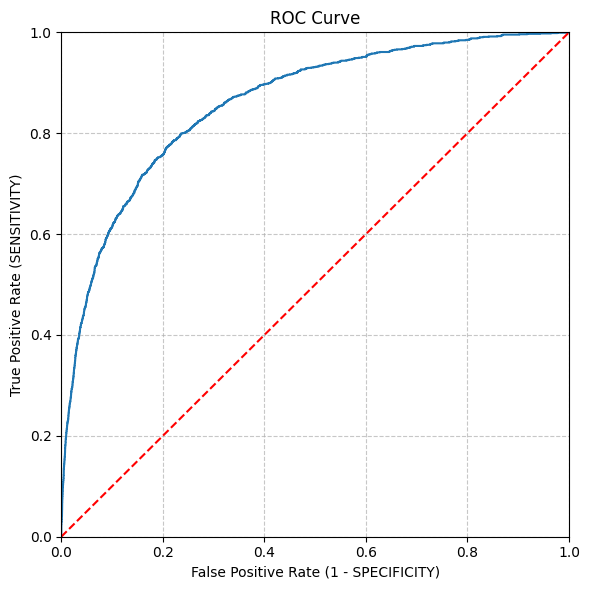

AUC Score: 0.8593845909001195
Accuracy: 94.03%


In [52]:
clf_scores_proba = clf.predict_proba(X_test_scaled)
clf_preds = clf_scores_proba[:, 1]
fpr, tpr, thresh = roc_curve(y_test, clf_preds)
plot_roc_curve(fpr, tpr)
print('AUC Score:', roc_auc_score(y_test, clf_preds))

y_pred = clf.predict(X_test_scaled)
preds = [round(value) for value in y_pred]
# round() because they're continuous values
accuracy = accuracy_score(y_test, preds)
print("Accuracy: %.2f%%" % (accuracy * 100.0))